# Tokenization & Embeddings

**Problem it solves:** a model can only multiply numbers. Your text has to become numbers first — without an endless vocabulary, and without making every sentence enormously long.

**How it works:** a tokenizer cuts text into **subwords** using merge rules learned from data (BPE). Each subword has an ID. Each ID maps to a vector.

**When it matters:** every bill you pay and every context limit you hit is counted in tokens. And every RAG system you build in [4_applied_ai](../../4_applied_ai/README.md) stands on embedding vectors.

In this notebook you **train a BPE tokenizer by hand**, then use a real embedding model. Read [2_tokenization_and_embeddings.md](../2_tokenization_and_embeddings.md) first.

## Step 1 — Why not just use words? Or letters?

Two obvious ideas, both broken. Let's break them on purpose.

In [1]:
corpus = '''the model reads the text and the model predicts the next token
a smaller model is faster and a bigger model is slower
tokenizers turn text into tokens and tokens into text
low lower lowest new newer newest wide wider widest'''

words = corpus.split()
vocab_words = sorted(set(words))
print(f"word-level vocabulary from this tiny corpus: {len(vocab_words)} words")

new_sentence = "the newest tokenizer is faster"
unknown = [w for w in new_sentence.split() if w not in vocab_words]
print(f"words in a NEW sentence that the vocabulary has never seen: {unknown}")
print("  -> a word-level model turns these into <UNK> and loses the meaning completely")

print(f"\ncharacter-level: vocabulary is only {len(set(corpus))} characters - nothing is ever unknown")
print(f"  but 'tokenizer' becomes {len('tokenizer')} steps instead of 1, and long = slow = expensive")

word-level vocabulary from this tiny corpus: 27 words
words in a NEW sentence that the vocabulary has never seen: ['tokenizer']
  -> a word-level model turns these into <UNK> and loses the meaning completely

character-level: vocabulary is only 24 characters - nothing is ever unknown
  but 'tokenizer' becomes 9 steps instead of 1, and long = slow = expensive


## Step 2 — Train BPE (Byte-Pair Encoding) yourself

The whole algorithm in four lines:

1. Start with single characters.
2. Count every neighbouring pair.
3. Merge the **most frequent** pair into one new token. Save that rule.
4. Repeat until you reach the vocabulary size you want.

`</w>` marks the end of a word, so `er` at the end of `lower` is treated differently from `er` in the middle of a word. Real tokenizers do the same thing with a space marker.

In [2]:
from collections import Counter

def initial_word_freqs(text):
    '''Each word becomes a tuple of characters, plus an end-of-word marker.'''
    freqs = Counter(text.split())
    return {tuple(word) + ("</w>",): count for word, count in freqs.items()}


def count_pairs(word_freqs):
    pairs = Counter()
    for symbols, freq in word_freqs.items():
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs


def apply_merge(pair, word_freqs):
    merged = {}
    for symbols, freq in word_freqs.items():
        out, i = [], 0
        while i < len(symbols):
            if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                out.append(symbols[i] + symbols[i + 1])   # glue the pair together
                i += 2
            else:
                out.append(symbols[i])
                i += 1
        merged[tuple(out)] = freq
    return merged


def train_bpe(text, n_merges):
    word_freqs = initial_word_freqs(text)
    merges = []
    for step in range(n_merges):
        pairs = count_pairs(word_freqs)
        if not pairs:
            break
        best, count = pairs.most_common(1)[0]
        merges.append(best)
        word_freqs = apply_merge(best, word_freqs)
        if step < 12:
            print(f"merge {step + 1:2d}: {best[0]!r} + {best[1]!r} -> {best[0] + best[1]!r}  (seen {count}x)")
    return merges


merges = train_bpe(corpus, n_merges=45)
print(f"\nlearned {len(merges)} merge rules")

merge  1: 'e' + 'r' -> 'er'  (seen 8x)
merge  2: 's' + '</w>' -> 's</w>'  (seen 7x)
merge  3: 't' + '</w>' -> 't</w>'  (seen 7x)
merge  4: 'er' + '</w>' -> 'er</w>'  (seen 7x)
merge  5: 'd' + 'e' -> 'de'  (seen 6x)
merge  6: 't' + 'o' -> 'to'  (seen 6x)
merge  7: 't' + 'h' -> 'th'  (seen 4x)
merge  8: 'th' + 'e' -> 'the'  (seen 4x)
merge  9: 'the' + '</w>' -> 'the</w>'  (seen 4x)
merge 10: 'm' + 'o' -> 'mo'  (seen 4x)
merge 11: 'mo' + 'de' -> 'mode'  (seen 4x)
merge 12: 'mode' + 'l' -> 'model'  (seen 4x)

learned 45 merge rules


## Step 3 — Encode with those rules

To tokenize a new word: split it into characters, then apply the saved merges **in the order they were learned**. Order matters — that is the whole trick.

Words the tokenizer saw often collapse into one or two tokens. Words it never saw fall apart into small pieces. Nothing is ever unknown.

In [3]:
def encode_word(word, merges):
    symbols = list(word) + ["</w>"]
    for a, b in merges:                       # merges applied in learned order
        out, i = [], 0
        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == a and symbols[i + 1] == b:
                out.append(a + b)
                i += 2
            else:
                out.append(symbols[i])
                i += 1
        symbols = out
    return symbols


def encode(text, merges):
    return [tok for word in text.split() for tok in encode_word(word, merges)]


for text in ["the model", "newest", "lowest", "unhappiness", "kubectl"]:
    tokens = encode(text, merges)
    print(f"{text:14s} -> {len(tokens)} tokens: {tokens}")

print("\n'the' and 'model' were common in the corpus, so they are single tokens.")
print("'unhappiness' and 'kubectl' were never seen, so they break into pieces - but never into <UNK>.")

the model      -> 2 tokens: ['the</w>', 'model</w>']
newest         -> 2 tokens: ['new', 'est</w>']
lowest         -> 2 tokens: ['low', 'est</w>']
unhappiness    -> 10 tokens: ['u', 'n', 'h', 'a', 'p', 'p', 'i', 'ne', 's', 's</w>']
kubectl        -> 8 tokens: ['k', 'u', 'b', 'e', 'c', 't', 'l', '</w>']

'the' and 'model' were common in the corpus, so they are single tokens.
'unhappiness' and 'kubectl' were never seen, so they break into pieces - but never into <UNK>.


## Step 4 — What this costs you in real money

Now use a **real** production tokenizer instead of our 45-rule toy.

`tiktoken` is what OpenAI models use. If it is not installed the cell below tells you, and everything still runs — but install it, because counting tokens is the cheapest measurement in the whole stack.

```
pip install tiktoken
```

In [4]:
try:
    import tiktoken
    enc = tiktoken.get_encoding("o200k_base")     # the modern OpenAI vocabulary
    count = lambda s: len(enc.encode(s))
    real = True
except ImportError:
    count = lambda s: max(1, len(s) // 4)         # rough fallback: ~4 characters per token
    real = False
    print("tiktoken not installed - using a rough 4-chars-per-token estimate.\n")

samples = {
    "English":        "The tokenizer turns text into numbers the model can use.",
    "Bangla":         "টোকেনাইজার টেক্সটকে সংখ্যায় রূপান্তর করে যা মডেল ব্যবহার করতে পারে।",
    "Hindi":          "टोकनाइज़र टेक्स्ट को संख्याओं में बदलता है जिसे मॉडल उपयोग कर सकता है।",
    "JSON":           '{"user_identifier": 42, "is_active_member": true, "display_name": "Sifat"}',
    "same as CSV":    "user_identifier,is_active_member,display_name\n42,true,Sifat",
    "UUID":           "550e8400-e29b-41d4-a716-446655440000",
    "Python code":    "def add(a, b):\n    return a + b",
}

base = count(samples["English"])
print(f"{'text':14s} {'chars':>6s} {'tokens':>7s} {'chars/token':>12s}")
for name, text in samples.items():
    n = count(text)
    print(f"{name:14s} {len(text):6d} {n:7d} {len(text) / n:12.1f}")

if real:
    print(f"\nThe Bangla and Hindi lines mean the same thing as the English one,")
    print(f"but cost {count(samples['Bangla']) / base:.1f}x and {count(samples['Hindi']) / base:.1f}x more tokens.")
    print("Same product, same prompt, several times the bill - and a smaller usable context window.")
    print(f"\nJSON costs {count(samples['JSON'])} tokens; the same data as CSV costs "
          f"{count(samples['same as CSV'])}. Free savings, no quality lost.")
    print(f"\nThe UUID is {len(samples['UUID'])} characters but "
          f"{count(samples['UUID'])} tokens - almost one token per character.")
    print("That is also why models are bad at counting letters: they never see letters.")

text            chars  tokens  chars/token
English            56      11          5.1
Bangla             68      24          2.8
Hindi              70      24          2.9
JSON               74      22          3.4
same as CSV        59      13          4.5
UUID               36      18          2.0
Python code        31      11          2.8

The Bangla and Hindi lines mean the same thing as the English one,
but cost 2.2x and 2.2x more tokens.
Same product, same prompt, several times the bill - and a smaller usable context window.

JSON costs 22 tokens; the same data as CSV costs 13. Free savings, no quality lost.

The UUID is 36 characters but 18 tokens - almost one token per character.
That is also why models are bad at counting letters: they never see letters.


## Step 5 — Embeddings: meaning as direction

A tokenizer gives you IDs. An **embedding model** gives you one vector for a whole piece of text, where similar meaning points in a similar direction.

We use Google's `gemini-embedding-001` on the free tier — the same `GEMINI_API_KEY` your [1_introduction notebook](../../1_introduction/basic_prompt.ipynb) already uses. The OpenAI equivalent is two lines different, and is shown in a comment.

Similarity is measured with **cosine similarity** — the angle between two vectors, ignoring length:

```
cos(a, b) = (a · b) / (|a| × |b|)
```

In [5]:
import os

import numpy as np
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
EMBED_MODEL = "gemini-embedding-001"

DIMS = 768   # this model can return up to 3072 numbers; fewer = cheaper to store and search


def embed(texts):
    '''One vector per input text.'''
    response = client.models.embed_content(
        model=EMBED_MODEL,
        contents=texts,
        config=types.EmbedContentConfig(output_dimensionality=DIMS),
    )
    return np.array([e.values for e in response.embeddings])


# The OpenAI version of the same thing:
#   from openai import OpenAI
#   client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
#   r = client.embeddings.create(model="text-embedding-3-small", input=texts)
#   vectors = np.array([d.embedding for d in r.data])

sentences = [
    "How do I reset my password?",              # 0
    "I forgot my login details",                # 1  - same meaning, different words
    "The pricing page shows our monthly plans",  # 2
    "How much does the subscription cost?",     # 3  - same meaning as 2
    "The movie was good",                       # 4
    "The movie was not good",                   # 5  - OPPOSITE meaning, similar words
]

vectors = embed(sentences)

print("model:", EMBED_MODEL)
print("vectors shape:", vectors.shape, "- one row per sentence,", vectors.shape[1], "numbers each")
print("first 8 numbers of sentence 0:", vectors[0][:8].round(4))

model: gemini-embedding-001
vectors shape: (6, 768) - one row per sentence, 768 numbers each
first 8 numbers of sentence 0: [ 0.0134  0.0058  0.0083 -0.0325  0.0002  0.0152 -0.0017 -0.0044]


In [6]:
def cosine_similarity(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))


pairs = [
    (0, 1, "different words, same meaning"),
    (2, 3, "different words, same meaning"),
    (0, 2, "unrelated topics"),
    (4, 5, "SIMILAR words, opposite meaning"),
]

for i, j, note in pairs:
    score = cosine_similarity(vectors[i], vectors[j])
    print(f"{score:.3f}  {note}")
    print(f"        {sentences[i]!r}")
    print(f"        {sentences[j]!r}\n")

print("Look at the last pair. 'good' and 'not good' score very high together.")
print("Embeddings capture TOPIC far better than they capture LOGIC.")
print("This is a real source of RAG bugs - retrieval happily returns the opposite of what you asked.")

0.652  different words, same meaning
        'How do I reset my password?'
        'I forgot my login details'

0.685  different words, same meaning
        'The pricing page shows our monthly plans'
        'How much does the subscription cost?'

0.486  unrelated topics
        'How do I reset my password?'
        'The pricing page shows our monthly plans'

0.741  SIMILAR words, opposite meaning
        'The movie was good'
        'The movie was not good'

Look at the last pair. 'good' and 'not good' score very high together.
Embeddings capture TOPIC far better than they capture LOGIC.
This is a real source of RAG bugs - retrieval happily returns the opposite of what you asked.


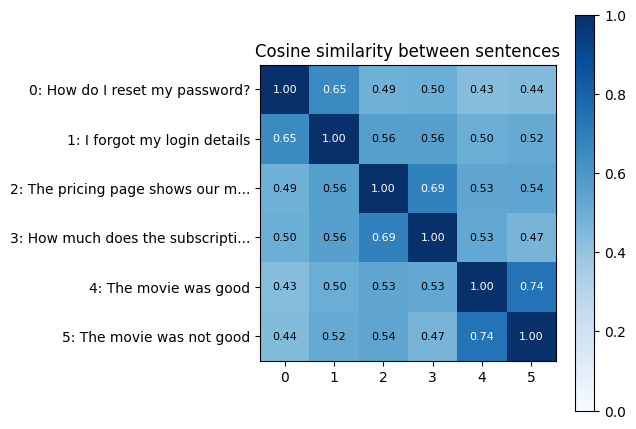

In [7]:
import matplotlib.pyplot as plt

n = len(sentences)
sim = np.array([[cosine_similarity(vectors[i], vectors[j]) for j in range(n)] for i in range(n)])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(sim, cmap="Blues", vmin=0, vmax=1)

labels = [s[:28] + ("..." if len(s) > 28 else "") for s in sentences]
ax.set_xticks(range(n), range(n))
ax.set_yticks(range(n), [f"{i}: {t}" for i, t in enumerate(labels)])
ax.set_title("Cosine similarity between sentences")

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if sim[i, j] > 0.6 else "black")

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Step 6 — Semantic search in six lines

This is the whole retrieval idea, before any vector database gets involved: embed the question, compare it against every document, return the closest ones. A vector database in [4_applied_ai](../../4_applied_ai/README.md) is this exact operation, made fast for millions of documents.

In [8]:
docs = [
    "To reset your password, click 'Forgot password' on the sign-in page.",
    "Our Pro plan costs $20 per month and includes unlimited projects.",
    "Support is available Monday to Friday, 9am to 6pm.",
    "You can export your data as CSV from the account settings page.",
]

doc_vectors = embed(docs)

question = "I can't log in, how do I get back into my account?"
q_vector = embed([question])[0]

scores = [cosine_similarity(q_vector, dv) for dv in doc_vectors]
ranked = sorted(zip(scores, docs), reverse=True)

print(f"question: {question}\n")
for score, doc in ranked:
    print(f"  {score:.3f}  {doc}")

question: I can't log in, how do I get back into my account?

  0.673  To reset your password, click 'Forgot password' on the sign-in page.
  0.582  Support is available Monday to Friday, 9am to 6pm.
  0.572  You can export your data as CSV from the account settings page.
  0.489  Our Pro plan costs $20 per month and includes unlimited projects.


## Your turn — modify and debug on purpose

Guess first, then run.

1. In Step 2, change `n_merges` to `5`, then to `200`. How does the token count for `"newest"` change? What is the trade-off between vocabulary size and sequence length?
2. In Step 3, tokenize a word from your own domain (`"microservice"`, `"terraform"`, your product name). How many pieces does it become, and what would that cost you at scale?
3. In Step 4, add a long sentence in your own language and compare its `chars/token` to English. Then work out: at $0.15 per million input tokens, how much more does 1 million requests cost in that language?
4. In Step 5, add the pair `"The server is down"` and `"The server is up"`. Guess the similarity before you run it. Were you close?
5. In Step 6, add a document that is *about* passwords but says the opposite of what the question needs. Does retrieval still rank it first? This is exactly why RAG systems need a reranker.
6. Without AI help, explain in your own words: *why does a tokenizer use subwords instead of words, and why does the same sentence cost more tokens in some languages?*